# SSE Detection Manuscript Figures and Tables

This notebook is the manuscript build sheet for SSE detection outputs. It loads the processed analysis tables, renders publication-context figures, and writes consistently named figure and table files under `sse_detection/manuscript`.


## Build Settings

All plots use the project `paper` context. Figure and table names are defined in the notebook rather than inside plotting helpers, so numbering and filenames can be changed in one place before export.


In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

%load_ext autoreload
%autoreload 2

PROJECT_ROOT = Path("/Users/ydnkka/Desktop/PhD Project/projects/scotland")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import utils  # noqa: E402
from sse_detection import lib as sselib  # noqa: E402

PLOT_CONTEXT = "paper"
SAVE_OUTPUTS = os.environ.get("SSE_SAVE_OUTPUTS", "1").lower() not in {"0", "false", "no"}
DISPLAY_FIGURES = os.environ.get("SSE_DISPLAY_FIGURES", "1").lower() not in {"0", "false", "no"}

OUTPUT_DIR = PROJECT_ROOT / "sse_detection" / "results" / "sse_outputs"
ASSOCIATION_DIR = PROJECT_ROOT / "sse_detection" / "results" / "association_outputs"
CLADE_SENSITIVITY_DIR = PROJECT_ROOT / "sse_detection" / "results" / "sensitivity_clade"
POLICY_DIR = PROJECT_ROOT / "sse_detection" / "results" / "policy_outputs"
VACCINATION_DIR = PROJECT_ROOT / "sse_detection" / "results" / "vaccination_outputs"
RESULTS_DIR = PROJECT_ROOT / "sse_detection" / "results"
GEOGRAPHY_PATH = PROJECT_ROOT / "data" / "processed" / "scotland_geography.parquet"
ANALYSIS_DATASET = PROJECT_ROOT / "data" / "processed" / "scotland_clustering_analysis_dataset.parquet"

EXPORT_DIR = PROJECT_ROOT / "sse_detection" / "manuscript"
FIG_DIR = EXPORT_DIR / "figures"
TABLE_DIR = EXPORT_DIR / "tables"
for directory in (FIG_DIR, TABLE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

utils.set_theme(context=PLOT_CONTEXT)

In [2]:
figure_exports: list[dict[str, object]] = []
table_exports: list[dict[str, object]] = []


def export_figure(
    fig,
    stem: str,
    *,
    width: utils.WIDTHS = "double",
    width_in: float | None = None,
    height_in: float | None = None,
    close_if_not_saved: bool = False,
) -> None:
    """Display and optionally save one manuscript figure."""
    if DISPLAY_FIGURES:
        display(fig)

    paths = {}
    if SAVE_OUTPUTS:
        paths = utils.save_figure(
            fig,
            FIG_DIR / stem,
            width=width,
            width_in=width_in,
            height_in=height_in,
            save_pdf=True,
            save_png=True,
        )
    elif close_if_not_saved or not DISPLAY_FIGURES:
        plt.close(fig)

    figure_exports.append(
        {
            "stem": stem,
            "width": width,
            "width_in": width_in,
            "height_in": height_in,
            "pdf": paths.get("pdf"),
            "png": paths.get("png"),
        }
    )


def export_table(table: pd.DataFrame, stem: str) -> None:
    """Save one manuscript table CSV and record its row/column count."""
    path = TABLE_DIR / f"{stem}.csv"
    if SAVE_OUTPUTS:
        table.to_csv(path, index=False)
    table_exports.append(
        {
            "stem": stem,
            "rows": len(table),
            "columns": len(table.columns),
            "path": path if SAVE_OUTPUTS else None,
        }
    )

## Load SSE Output Tables

These are the static outputs from the SSE detection pipeline. The summary table is exported as the first manuscript table because it anchors the denominator for downstream figures.


In [3]:
outs = sselib.load_sse_outputs(OUTPUT_DIR)
node_stats = sselib.prepare_node_stats_for_association(outs.node_stats)
edge_table = outs.edge_table
candidates = node_stats.loc[node_stats["sse_candidate"]].copy()

min_size = int(node_stats.loc[node_stats["sse_candidate"], "cluster_size"].min())
backgrounds = node_stats[
    (node_stats["cluster_size"].ge(min_size))
    & (~node_stats["sse_candidate"])
]
component_col = "meta_cluster_id"

output_summary = pd.DataFrame([
    ("node-clusters", len(node_stats)),
    ("directed edges", len(edge_table)),
    ("connected components", node_stats[component_col].nunique()),
    ("high-priority candidate nodes", int(node_stats["sse_candidate"].sum())),
    ("candidate share of nodes", float(node_stats["sse_candidate"].mean())),
    (f"background nodes (cluster size >= {min_size})", len(backgrounds)),
    (
        f"background share of nodes (cluster size >= {min_size})",
        len(backgrounds) / len(node_stats),
    ),
    ("unique candidate signatures", candidates["sse_signature"].nunique()),
], columns=["quantity", "value"])

output_summary["display_value"] = output_summary["value"].map(
    lambda value: (
        f"{value:,.1%}"
        if isinstance(value, float) and abs(value) < 1
        else f"{value:,.0f}"
        if pd.notna(value)
        else "NA"
    )
)

display(output_summary[["quantity", "display_value"]])
export_table(output_summary, "table01_sse_output_summary")


,quantity,display_value
0,node-clusters,"99,006"
1,directed edges,"41,747"
2,connected components,"57,354"
3,high-priority candidate nodes,614
4,candidate share of nodes,0.6%
5,background nodes (cluster size >= 6),"12,445"
6,background share of nodes (cluster size >= 6),12.6%
7,unique candidate signatures,2


## Descriptive SSE Figures

These figures describe the detected candidate nodes, their meta-cluster context, temporal dynamics, and score distributions. The filenames use the manuscript figure order plus short content labels.


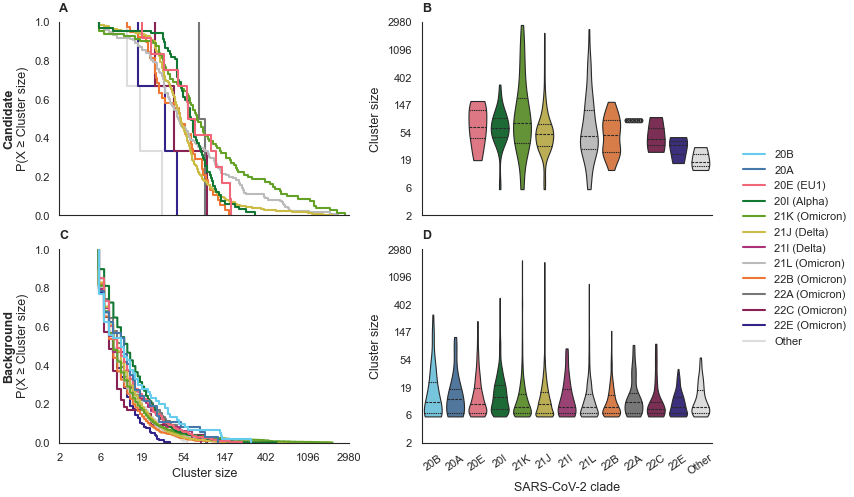

In [4]:
fig = sselib.plot_cluster_size_distribution(
    node_stats,
    min_size=min_size,
    context=PLOT_CONTEXT,
    width="double",
    height_in=5,
)
export_figure(
    fig, 
    "fig01_cluster_size_distribution", 
    width="double", 
    height_in=5
    )

In [ ]:
component_summary = (
    node_stats.groupby("meta_cluster_id", dropna=False)
    .agg(
        n_nodes=("cluster_id", "nunique"),
        n_candidates=("sse_candidate", "sum"),
        max_cluster_size=("cluster_size", "max"),
        first_window=("window_idx", "min"),
        last_window=("window_idx", "max"),
    )
    .reset_index()
)
component_summary = component_summary.loc[component_summary["n_candidates"].gt(0)]
component_summary = component_summary.sort_values(
    ["n_candidates", "n_nodes", "max_cluster_size", "meta_cluster_id"],
    ascending=[False, False, False, True],
)
exemplar_meta_clusters = component_summary["meta_cluster_id"].head(10)

display(component_summary.head(10))

,meta_cluster_id,n_nodes,n_candidates,max_cluster_size,first_window,last_window
0,CC00001,254,14,1087,24,27
1,CC00002,222,8,2666,37,42
3,CC00004,174,8,1119,46,48
8,CC00009,64,7,509,27,32
6,CC00007,76,6,307,16,20
5,CC00006,80,5,714,44,46
10,CC00011,61,4,2000,23,25
19,CC00020,36,4,231,24,27
41,CC00042,19,4,138,7,9
57,CC00058,16,4,101,46,48


Selected component for subgraph: CC00001


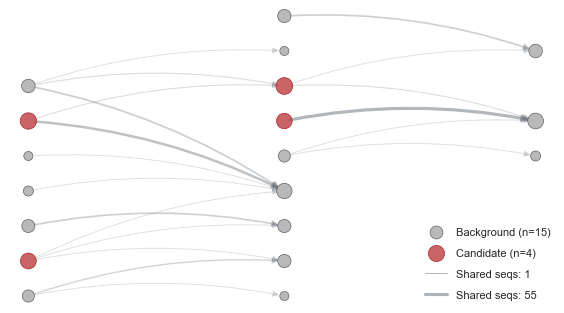

In [6]:
fig = sselib.plot_meta_cluster_subgraph(
    node_stats=node_stats,
    edge_table=edge_table,
    meta_cluster_id="CC00042",
    annotate_top_n=0,
    layout_method="dot",
    width="double",
    height_in=4,
    context=PLOT_CONTEXT,
    edge_curve=-0.1
)
export_figure(
    fig,
    "fig02_candidate_component_subgraph",
    width="double",
    height_in=4,
)


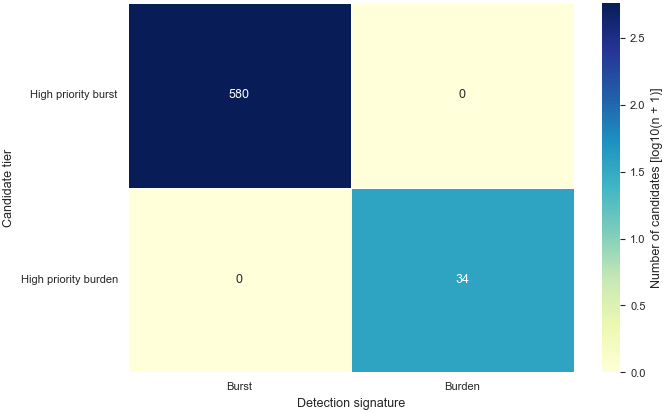

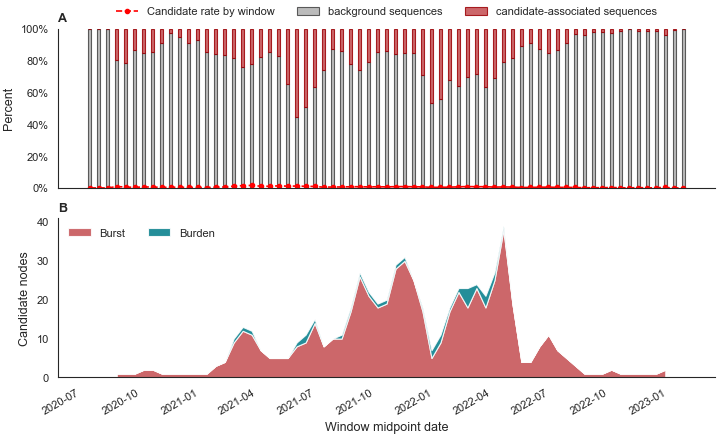

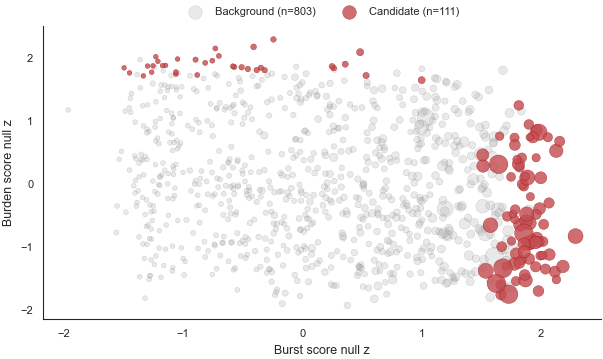

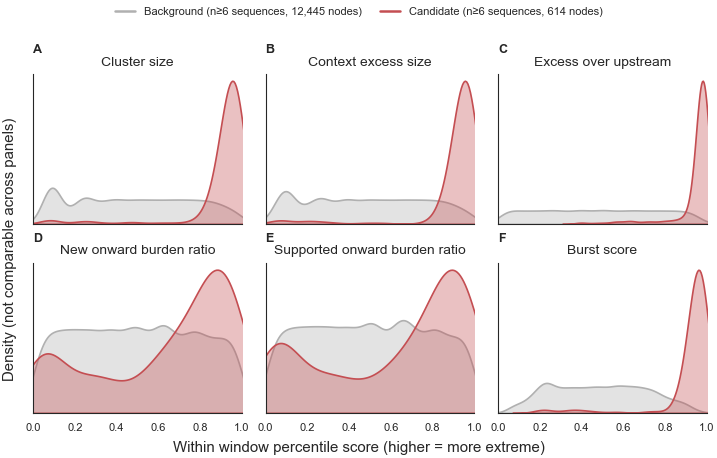

In [7]:
descriptive_figures = [
    (
        "fig03_candidate_signature_heatmap",
        sselib.plot_role_dynamic_heatmap(
            candidates,
            context=PLOT_CONTEXT,
            height_in=4.8,
        ),
        {"width": "double", "height_in": 4.8},
    ),
    (
        "fig04_candidate_rate_over_time",
        sselib.plot_candidate_rate_over_time(
            node_stats,
            context=PLOT_CONTEXT,
            height_in=4.4,
        ),
        {"width": "double", "height_in": 4.4},
    ),
    (
        "fig05_core_metric_space",
        sselib.plot_core_metric_space(
            node_stats,
            min_size=min_size,
            context=PLOT_CONTEXT,
            height_in=3.8,
        ),
        {"width": "double", "height_in": 3.8},
    ),
    (
        "fig06_composite_score_distributions",
        sselib.plot_composite_distributions(
            node_stats,
            min_size=min_size,
            context=PLOT_CONTEXT,
            width="double",
            height_in=4.2,
        ),
        {"width": "double", "height_in": 4.2},
    ),
]

for stem, fig, kwargs in descriptive_figures:
    export_figure(fig, stem, **kwargs)

## Composition and Mixing Breakdown Figures

Each figure pairs sequence-level candidate/background category shares with node-level within-cluster mixing-score distributions for the same predictor family.


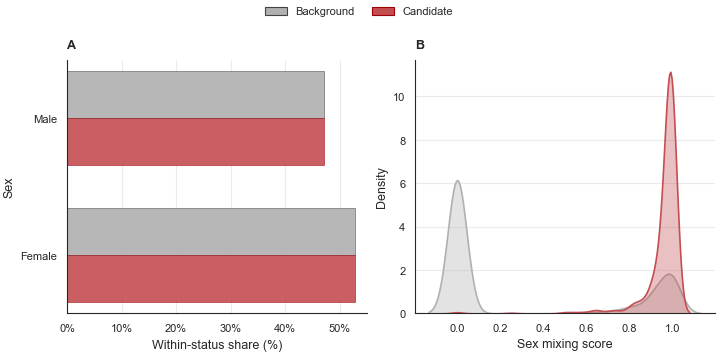

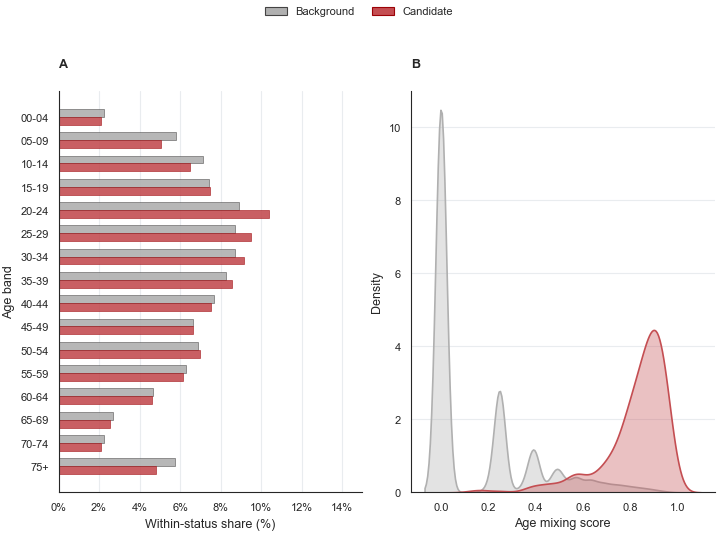

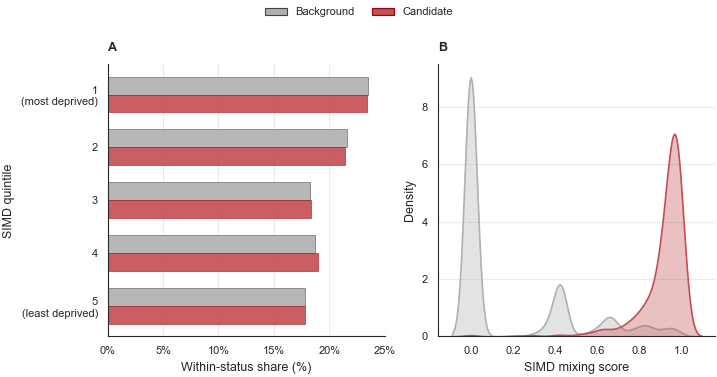

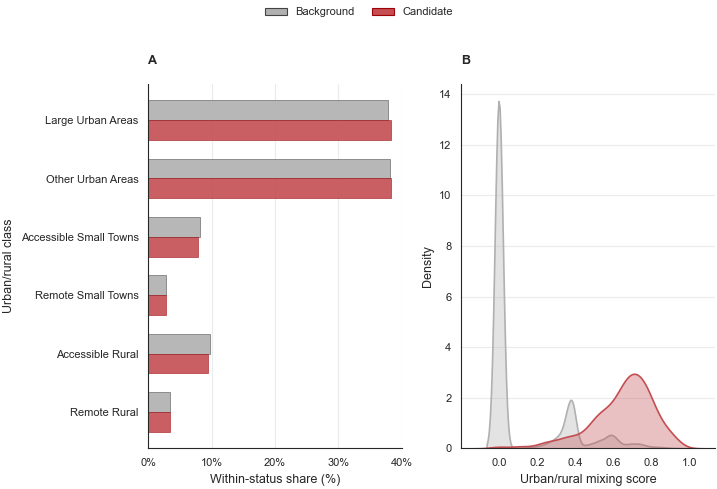

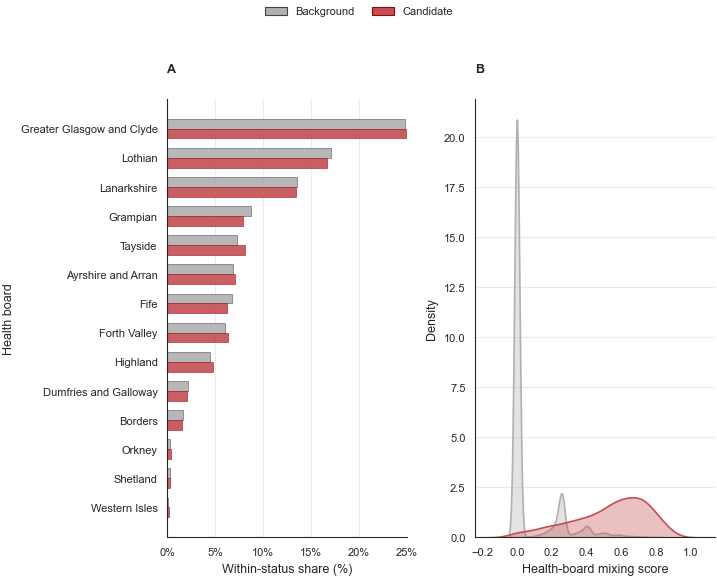

In [8]:
association_frames = sselib.load_association_frames(
    output_dir=OUTPUT_DIR,
    run_composition=True,
)
individual_level = association_frames.composition_base
node_level = association_frames.node_stats

socio_demo_mixing_specs = [
    ("fig07a_sex_mixing_breakdown", "sex", "sex_entropy_obs", "Sex mixing score", "Sex", 3.2),
    ("fig07b_age_mixing_breakdown", "age_band", "age_entropy_obs", "Age mixing score", "Age band", 4.8),
    ("fig07c_simd_mixing_breakdown", "dz_simd_quintile", "simd_entropy_obs", "SIMD mixing score", "SIMD quintile", 3.4),
    (
        "fig07d_urban_rural_mixing_breakdown",
        "dz_urban_rural_class",
        "urban_rural_entropy_obs",
        "Urban/rural mixing score",
        "Urban/rural class",
        4.4,
    ),
    ("fig07e_health_board_mixing_breakdown", "dz_health_board", "health_board_entropy_obs", "Health-board mixing score", "Health board", 5.2),
]

for stem, column, score, mixing_label, category_label, height in socio_demo_mixing_specs:
    fig = sselib.plot_socio_demo_breakdown(
        node_level,
        score=score,
        labels=(mixing_label, category_label),
        individual_data=individual_level,
        category_col=column,
        status_col="candidate",
        sequence_col="sequence_id",
        unit="sequences",
        context=PLOT_CONTEXT,
        height_in=height,
    )
    export_figure(fig, stem, width="double", height_in=height)


## Regression Association Tables

The association pipeline writes separate composition and mixing CSVs. This section normalizes those tables and exports manuscript-facing Wald, odds-ratio, and fit-statistics tables.


In [9]:
def read_analysis_table(path: Path) -> pd.DataFrame:
    table = pd.read_csv(path, skipinitialspace=True)
    table.columns = [str(col).strip() for col in table.columns]
    for col in table.select_dtypes(include=["object", "string"]).columns:
        present = table[col].notna()
        table.loc[present, col] = table.loc[present, col].astype(str).str.strip()
    return table


required_association_files = {
    "composition_wald": "composition_wald.csv",
    "composition_or": "composition_odds_ratios.csv",
    "composition_fit": "composition_fit_stats.csv",
    "mixing_wald": "mixing_wald.csv",
    "mixing_or": "mixing_odds_ratios.csv",
    "mixing_fit": "mixing_fit_stats.csv",
}

association_tables = {
    key: read_analysis_table(ASSOCIATION_DIR / filename)
    for key, filename in required_association_files.items()
}

composition_wald = association_tables["composition_wald"]
composition_or = association_tables["composition_or"]
composition_fit = association_tables["composition_fit"]
mixing_wald = association_tables["mixing_wald"]
mixing_or = association_tables["mixing_or"]
mixing_fit = association_tables["mixing_fit"]

In [10]:
MIXING_REFERENCE = "per 1-SD null-model expectation"


def fill_reference_scale(table: pd.DataFrame, value: str) -> pd.DataFrame:
    table = table.copy()
    if "Reference/scale" in table.columns:
        table["Reference/scale"] = (
            table["Reference/scale"].replace("", pd.NA).fillna(value)
        )
    return table


regression_tables = {
    "table02_composition_wald_tests": sselib.make_regression_wald_table(
        composition_wald,
        domain="composition",
    ),
    "table03_composition_odds_ratios": sselib.make_regression_odds_ratio_table(
        composition_or,
        domain="composition",
    ),
    "table04_composition_fit_stats": sselib.make_regression_fit_table(
        composition_fit,
        domain="composition",
    ),
    "table05_mixing_wald_tests": fill_reference_scale(
        sselib.make_regression_wald_table(
            mixing_wald,
            domain="node_mixing",
        ),
        MIXING_REFERENCE,
    ),
    "table06_mixing_odds_ratios": fill_reference_scale(
        sselib.make_regression_odds_ratio_table(
            mixing_or,
            domain="node_mixing",
        ),
        MIXING_REFERENCE,
    ),
    "table07_mixing_fit_stats": sselib.make_regression_fit_table(
        mixing_fit,
        domain="node_mixing",
    ),
}

for stem, table in regression_tables.items():
    export_table(table, stem)

display(pd.DataFrame(table_exports).tail(len(regression_tables)))

,stem,rows,columns,path
1,table02_composition_wald_tests,20,9,/Users/ydnkka/Desktop/PhD Project/projects/sco...
2,table03_composition_odds_ratios,152,9,/Users/ydnkka/Desktop/PhD Project/projects/sco...
3,table04_composition_fit_stats,12,10,/Users/ydnkka/Desktop/PhD Project/projects/sco...
4,table05_mixing_wald_tests,18,8,/Users/ydnkka/Desktop/PhD Project/projects/sco...
5,table06_mixing_odds_ratios,32,8,/Users/ydnkka/Desktop/PhD Project/projects/sco...
6,table07_mixing_fit_stats,18,9,/Users/ydnkka/Desktop/PhD Project/projects/sco...


## Regression Association Figures

The Wald heatmap uses the omnibus test tables. The forest plot and map use odds ratios from the primary single/joint specifications, keeping the presentation focused on interpretable effect sizes.


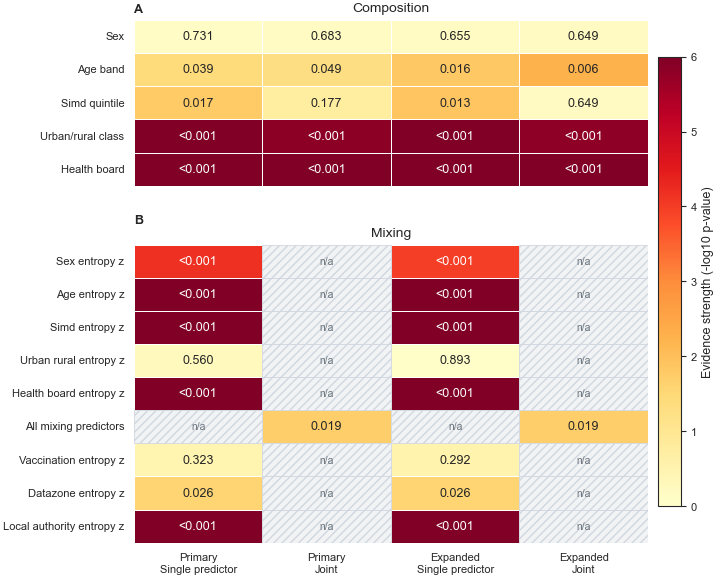

In [11]:
fig = sselib.plot_regression_wald_heatmap(
    composition_wald,
    mixing_wald,
    context=PLOT_CONTEXT,
    width="double",
    height_in=5.8,
    cap_neg_log10_p=6,
)
export_figure(
    fig,
    "fig08_regression_wald_heatmap",
    width="double",
    height_in=5.8,
)

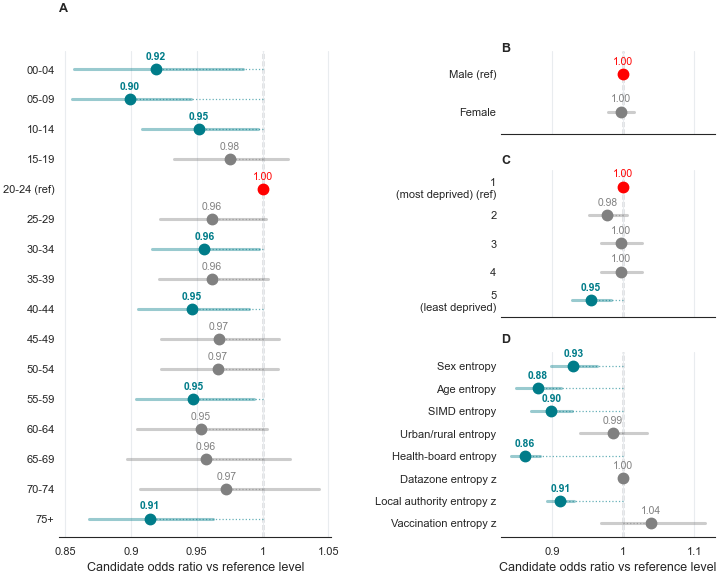

In [12]:
fig = sselib.plot_age_sex_simd_forest(
    composition_odds_ratios=composition_or,
    mixing_odds_ratios=mixing_or,
    predictor_set="single",
    model_set="primary",
    context=PLOT_CONTEXT,
    width="double",
    height_in=5.8,
)
export_figure(
    fig,
    "fig09_age_sex_simd_mixing_forest_single_primary",
    width="double",
    height_in=5.8,
)

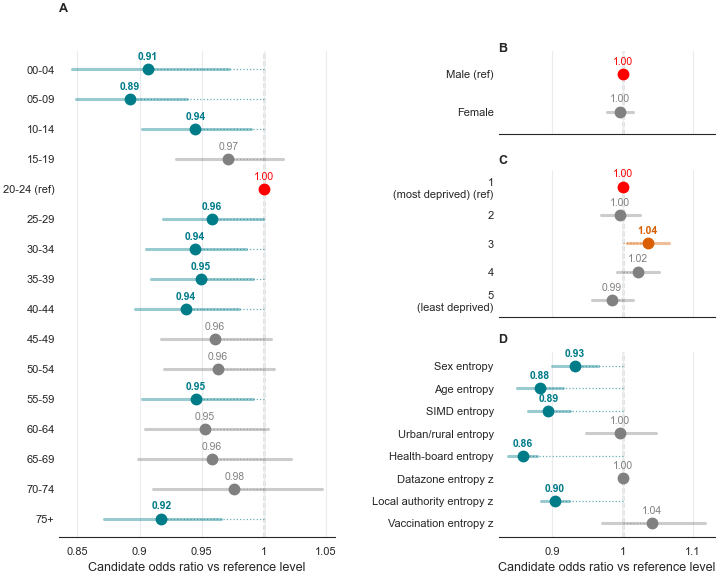

In [13]:
fig = sselib.plot_age_sex_simd_forest(
    composition_odds_ratios=composition_or,
    mixing_odds_ratios=mixing_or,
    predictor_set="single",
    model_set="expanded",
    context=PLOT_CONTEXT,
    width="double",
    height_in=5.8,
)
export_figure(
    fig,
    "fig09_age_sex_simd_mixing_forest_single_expanded",
    width="double",
    height_in=5.8,
)

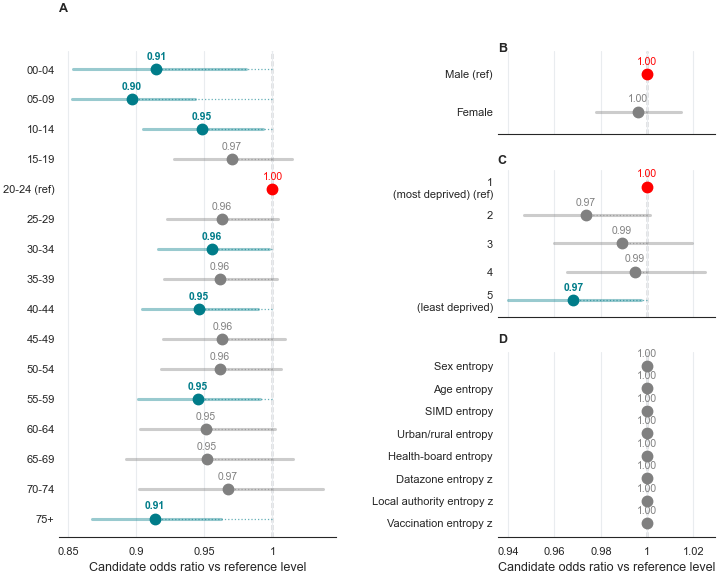

In [14]:
fig = sselib.plot_age_sex_simd_forest(
    composition_odds_ratios=composition_or,
    mixing_odds_ratios=mixing_or,
    predictor_set="joint",
    model_set="primary",
    context=PLOT_CONTEXT,
    width="double",
    height_in=5.8,
)
export_figure(
    fig,
    "fig09_age_sex_simd_mixing_forest_joint_primary",
    width="double",
    height_in=5.8,
)

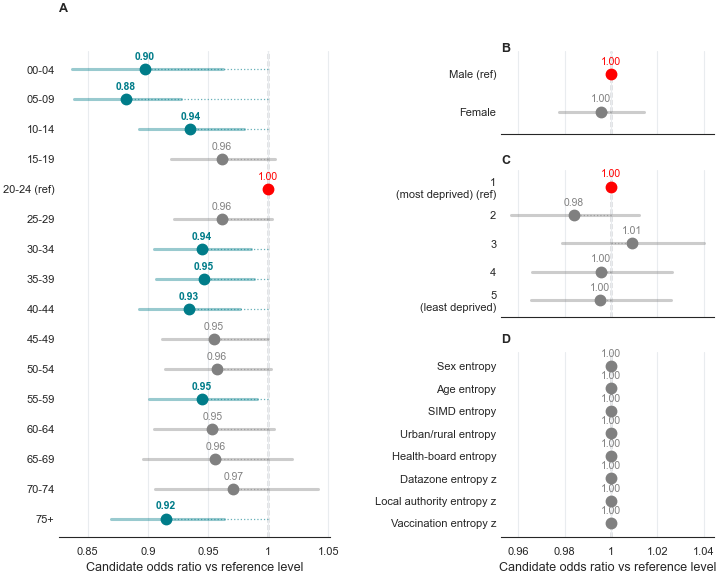

In [15]:
fig = sselib.plot_age_sex_simd_forest(
    composition_odds_ratios=composition_or,
    mixing_odds_ratios=mixing_or,
    predictor_set="joint",
    model_set="expanded",
    context=PLOT_CONTEXT,
    width="double",
    height_in=5.8,
)
export_figure(
    fig,
    "fig09_age_sex_simd_mixing_forest_joint_expanded",
    width="double",
    height_in=5.8,
)

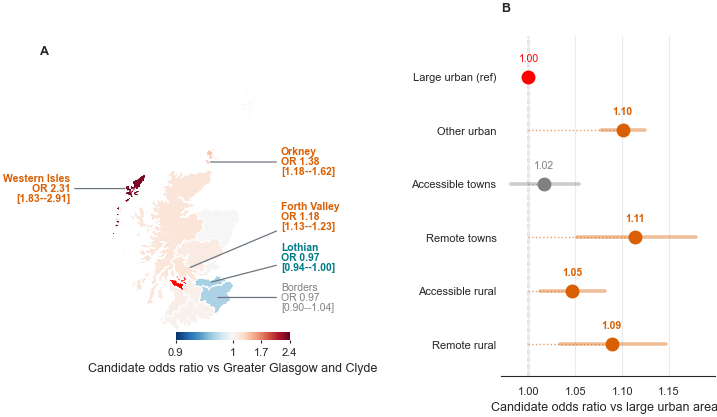

In [16]:
fig = sselib.plot_health_board_enrichment_map(
    GEOGRAPHY_PATH,
    composition_or,
    predictor_set="single",
    model_set="primary",
    context=PLOT_CONTEXT,
    width="double",
    height_in=4.2,
)
export_figure(
    fig,
    "fig10_health_board_urban_rural_enrichment_single_primary",
    width="double",
    height_in=4.2,
)

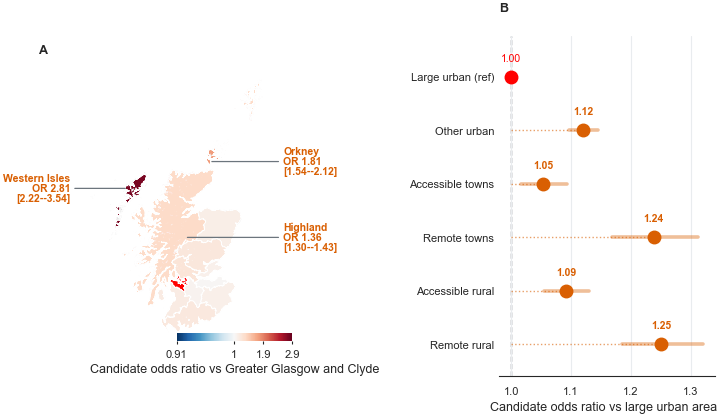

In [17]:
fig = sselib.plot_health_board_enrichment_map(
    GEOGRAPHY_PATH,
    composition_or,
    predictor_set="single",
    model_set="expanded",
    context=PLOT_CONTEXT,
    width="double",
    height_in=4.2,
)
export_figure(
    fig,
    "fig10_health_board_urban_rural_enrichment_single_expanded",
    width="double",
    height_in=4.2,
)

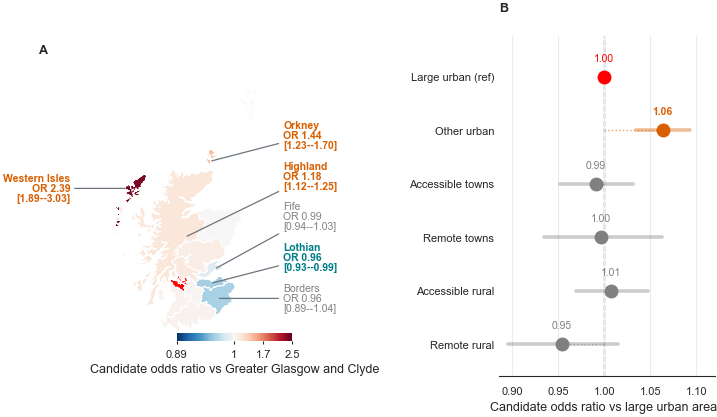

In [18]:
fig = sselib.plot_health_board_enrichment_map(
    GEOGRAPHY_PATH,
    composition_or,
    predictor_set="joint",
    model_set="primary",
    context=PLOT_CONTEXT,
    width="double",
    height_in=4.2,
)
export_figure(
    fig,
    "fig10_health_board_urban_rural_enrichment_joint_primary",
    width="double",
    height_in=4.2,
)

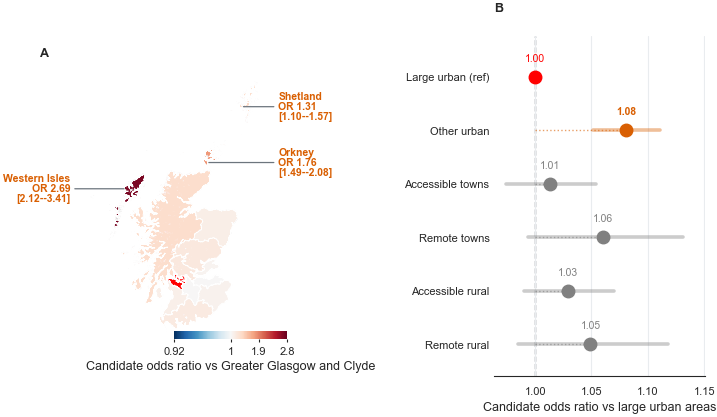

In [19]:
fig = sselib.plot_health_board_enrichment_map(
    GEOGRAPHY_PATH,
    composition_or,
    predictor_set="joint",
    model_set="expanded",
    context=PLOT_CONTEXT,
    width="double",
    height_in=4.2,
)
export_figure(
    fig,
    "fig10_health_board_urban_rural_enrichment_joint_expanded",
    width="double",
    height_in=4.2,
)

## Sensitivity Analysis Figure

This matrix summarizes whether composition and mixing Wald tests remain significant across sensitivity runs, including the joint mixing row where available.


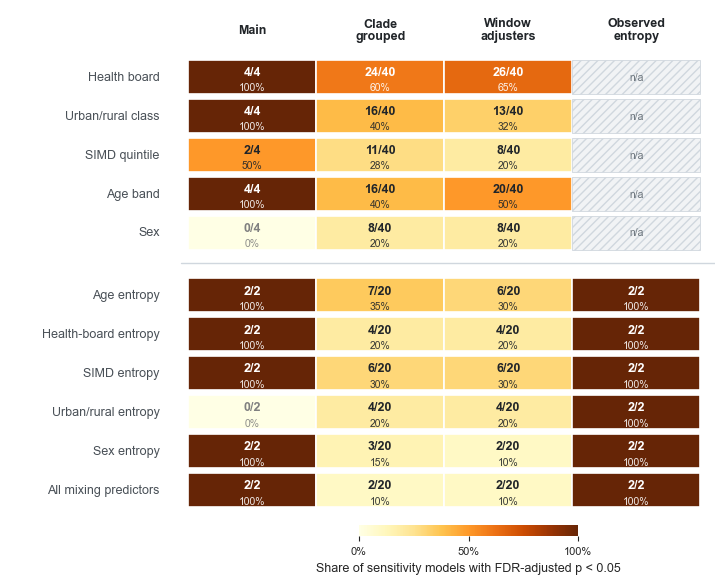

In [20]:
fig = sselib.plot_sensitivity_matrix(
    RESULTS_DIR,
    context=PLOT_CONTEXT,
    width="double",
    height_in=5.8,
)
export_figure(
    fig,
    "fig11_sensitivity_wald_matrix",
    width="double",
    height_in=5.8,
)

## Clade-Stratified Sensitivity Figures and Tables

The sensitivity helper returns dictionaries of figures and summary tables without saving. The notebook maps those stable clade-sensitivity keys to manuscript filenames below.


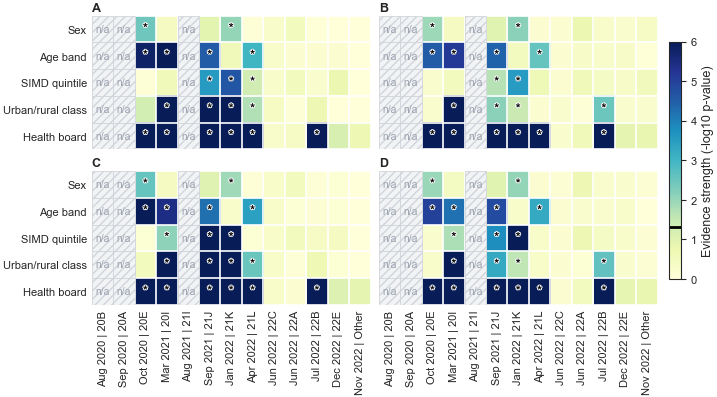

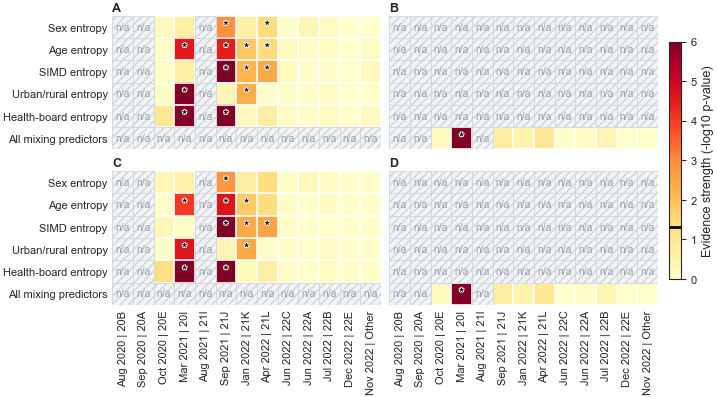

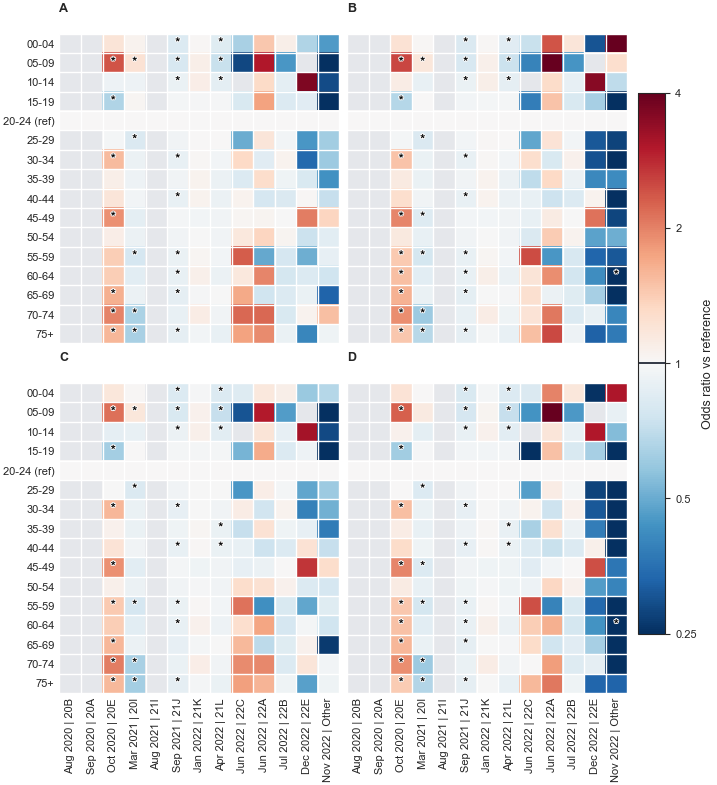

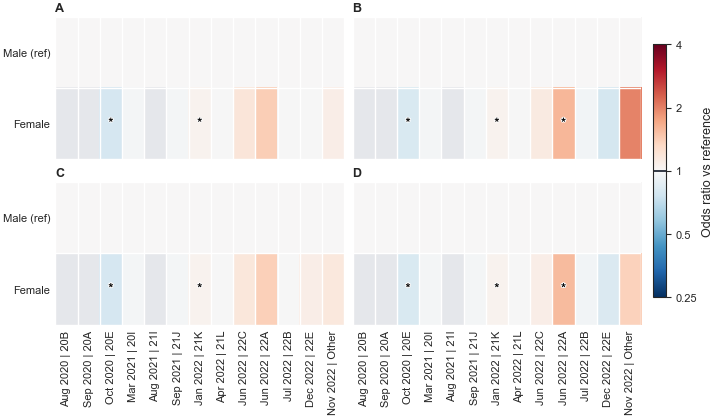

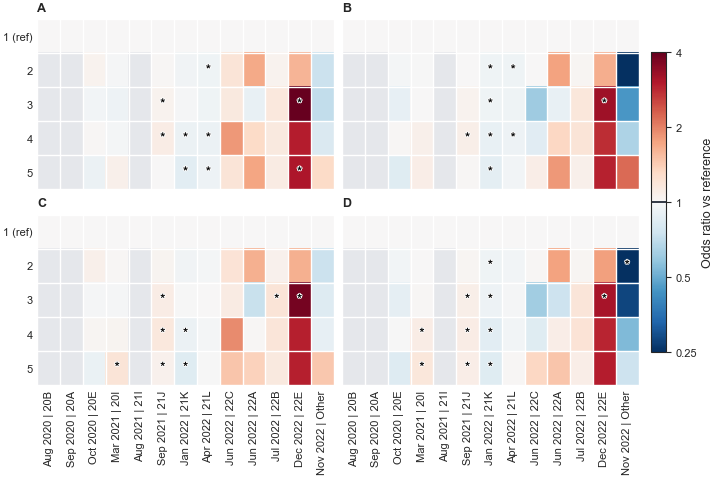

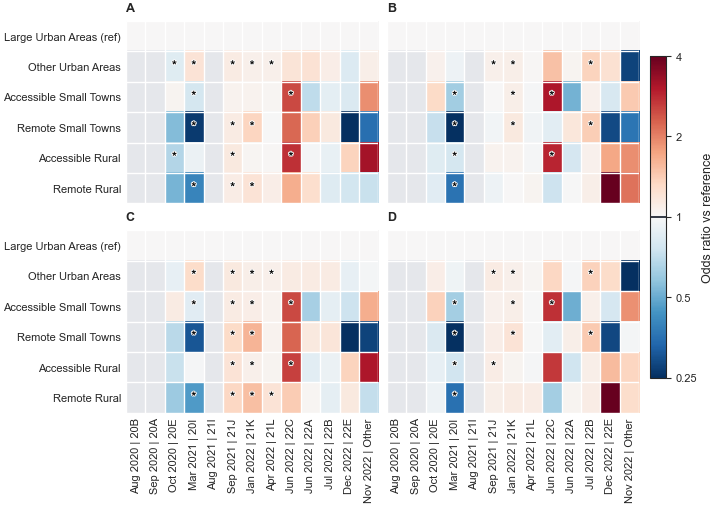

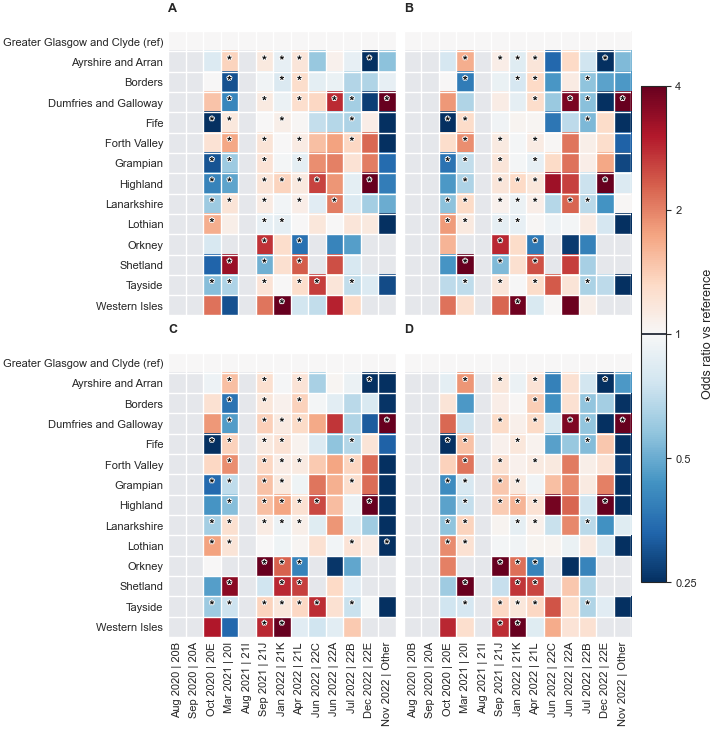

In [21]:
sensitivity_figures, sensitivity_tables = sselib.make_sensitivity_analysis_outputs(
    results_dir=CLADE_SENSITIVITY_DIR,
    analysis_dataset=ANALYSIS_DATASET,
)

sensitivity_figure_names = {
    "clade_composition_significance": "fig12_clade_composition_wald_heatmap",
    "clade_mixing_significance": "fig13_clade_mixing_wald_heatmap",
    "clade_composition_or_age_band": "fig14_clade_age_band_or_heatmap",
    "clade_composition_or_sex": "fig15_clade_sex_or_heatmap",
    "clade_composition_or_simd_quintile": "fig16_clade_simd_or_heatmap",
    "clade_composition_or_urban_rural_class": "fig17_clade_urban_rural_or_heatmap",
    "clade_composition_or_health_board": "fig18_clade_health_board_or_heatmap",
}

for source_key, stem in sensitivity_figure_names.items():
    if source_key in sensitivity_figures:
        export_figure(sensitivity_figures[source_key], stem, width="double")


## Context Figures


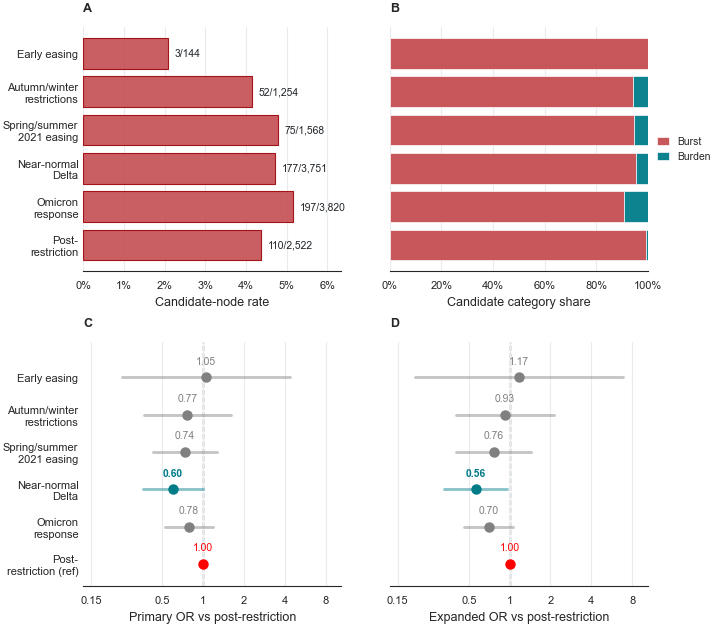

In [22]:
policy_figures = sselib.make_policy_figures(
    results_dir=POLICY_DIR,
    context=PLOT_CONTEXT,
    width="double",
    height_in=6.3,
)

if "policy_report" in policy_figures:
    export_figure(
        policy_figures["policy_report"],
        "fig19_policy_context",
        width="double",
        height_in=6.3,
    )

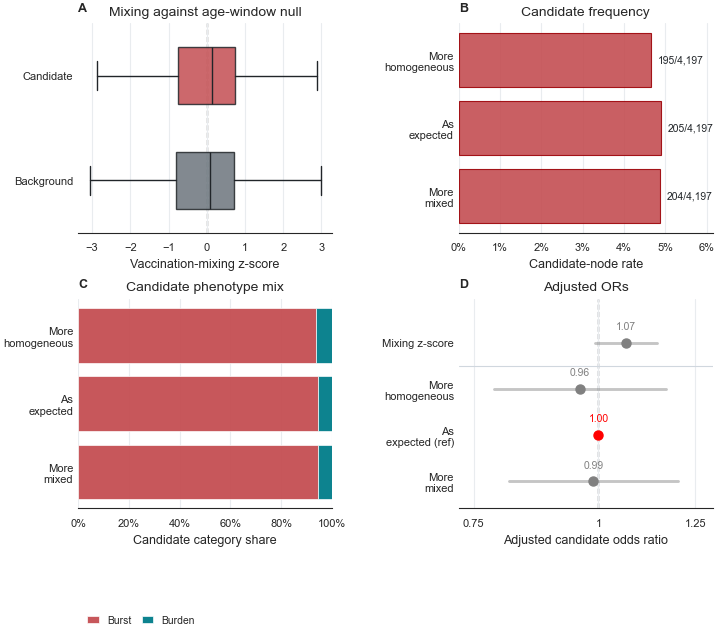

In [23]:
vaccination_figures = sselib.make_vaccination_figures(
    results_dir=VACCINATION_DIR,
    context=PLOT_CONTEXT,
    width="double",
    height_in=6.3,
)

if "vaccination_report" in vaccination_figures:
    export_figure(
        vaccination_figures["vaccination_report"],
        "fig20_vaccination_context",
        width="double",
        height_in=6.3,
    )


In [24]:
sensitivity_table_names = {
    "clade_composition_significance_table": "table08_clade_composition_wald_summary",
    "clade_mixing_significance_table": "table09_clade_mixing_wald_summary",
    "clade_composition_or_age_band_table": "table10_clade_age_band_or_summary",
    "clade_composition_or_sex_table": "table11_clade_sex_or_summary",
    "clade_composition_or_simd_quintile_table": "table12_clade_simd_or_summary",
    "clade_composition_or_urban_rural_class_table": "table13_clade_urban_rural_or_summary",
    "clade_composition_or_health_board_table": "table14_clade_health_board_or_summary",
}

for source_key, stem in sensitivity_table_names.items():
    if source_key in sensitivity_tables:
        export_table(sensitivity_tables[source_key], stem)

if sensitivity_tables:
    display(pd.DataFrame(table_exports).tail(len(sensitivity_table_names)))


,stem,rows,columns,path
7,table08_clade_composition_wald_summary,260,10,/Users/ydnkka/Desktop/PhD Project/projects/sco...
8,table09_clade_mixing_wald_summary,312,10,/Users/ydnkka/Desktop/PhD Project/projects/sco...
9,table10_clade_age_band_or_summary,832,10,/Users/ydnkka/Desktop/PhD Project/projects/sco...
10,table11_clade_sex_or_summary,104,10,/Users/ydnkka/Desktop/PhD Project/projects/sco...
11,table12_clade_simd_or_summary,260,10,/Users/ydnkka/Desktop/PhD Project/projects/sco...
12,table13_clade_urban_rural_or_summary,312,10,/Users/ydnkka/Desktop/PhD Project/projects/sco...
13,table14_clade_health_board_or_summary,728,10,/Users/ydnkka/Desktop/PhD Project/projects/sco...


## Export Index

The final two tables are a quick audit trail for files produced by this run. They are not manuscript tables; they help check names, dimensions, and destinations.


In [25]:
figure_export_index = pd.DataFrame(figure_exports)
table_export_index = pd.DataFrame(table_exports)

display(figure_export_index)
display(table_export_index)

,stem,width,width_in,height_in,pdf,png
0,fig01_cluster_size_distribution,double,None,5.0,/Users/ydnkka/Desktop/PhD Project/projects/sco...,/Users/ydnkka/Desktop/PhD Project/projects/sco...
1,fig02_candidate_component_subgraph,double,None,4.0,/Users/ydnkka/Desktop/PhD Project/projects/sco...,/Users/ydnkka/Desktop/PhD Project/projects/sco...
2,fig03_candidate_signature_heatmap,double,None,4.8,/Users/ydnkka/Desktop/PhD Project/projects/sco...,/Users/ydnkka/Desktop/PhD Project/projects/sco...
3,fig04_candidate_rate_over_time,double,None,4.4,/Users/ydnkka/Desktop/PhD Project/projects/sco...,/Users/ydnkka/Desktop/PhD Project/projects/sco...
4,fig05_core_metric_space,double,None,3.8,/Users/ydnkka/Desktop/PhD Project/projects/sco...,/Users/ydnkka/Desktop/PhD Project/projects/sco...
5,fig06_composite_score_distributions,double,None,4.2,/Users/ydnkka/Desktop/PhD Project/projects/sco...,/Users/ydnkka/Desktop/PhD Project/projects/sco...
6,fig07a_sex_mixing_breakdown,double,None,3.2,/Users/ydnkka/Desktop/PhD Project/projects/sco...,/Users/ydnkka/Desktop/PhD Project/projects/sco...
7,fig07b_age_mixing_breakdown,double,None,4.8,/Users/ydnkka/Desktop/PhD Project/projects/sco...,/Users/ydnkka/Desktop/PhD Project/projects/sco...
8,fig07c_simd_mixing_breakdown,double,None,3.4,/Users/ydnkka/Desktop/PhD Project/projects/sco...,/Users/ydnkka/Desktop/PhD Project/projects/sco...
9,fig07d_urban_rural_mixing_breakdown,double,None,4.4,/Users/ydnkka/Desktop/PhD Project/projects/sco...,/Users/ydnkka/Desktop/PhD Project/projects/sco...


,stem,rows,columns,path
0,table01_sse_output_summary,8,3,/Users/ydnkka/Desktop/PhD Project/projects/sco...
1,table02_composition_wald_tests,20,9,/Users/ydnkka/Desktop/PhD Project/projects/sco...
2,table03_composition_odds_ratios,152,9,/Users/ydnkka/Desktop/PhD Project/projects/sco...
3,table04_composition_fit_stats,12,10,/Users/ydnkka/Desktop/PhD Project/projects/sco...
4,table05_mixing_wald_tests,18,8,/Users/ydnkka/Desktop/PhD Project/projects/sco...
5,table06_mixing_odds_ratios,32,8,/Users/ydnkka/Desktop/PhD Project/projects/sco...
6,table07_mixing_fit_stats,18,9,/Users/ydnkka/Desktop/PhD Project/projects/sco...
7,table08_clade_composition_wald_summary,260,10,/Users/ydnkka/Desktop/PhD Project/projects/sco...
8,table09_clade_mixing_wald_summary,312,10,/Users/ydnkka/Desktop/PhD Project/projects/sco...
9,table10_clade_age_band_or_summary,832,10,/Users/ydnkka/Desktop/PhD Project/projects/sco...
